In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Leer el dataset
df = pd.read_csv(r"../Datos/Accidentes de Transito - Dataset.csv")

En este proyecto se excluyó el periodo comprendido entre marzo de 2020 y agosto de 2021, correspondiente a la pandemia de COVID-19. Se consideró que este intervalo no representa condiciones normales de tráfico, ya que las restricciones de movilidad y demás medidas sanitarias generan un comportamiento atípico en la accidentalidad. Por esta razón, el análisis se centra únicamente en periodos que reflejan condiciones normales de circulación vehicular.

Las variables Días Hábiles del mes e Inicio de Clases fueron calculadas manualmente con base en el calendario oficial de cada año.

## Información del conjunto de datos

In [ ]:
# Vista general del dataset
df.head()

,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
0,Enero,2017,2683,27.15,0.00,22,0,0.77,3237,309.60
1,Febrero,2017,2606,27.35,18.50,20,0,0.75,2683,312.23
2,Marzo,2017,3033,28.55,6.35,23,1,0.73,2606,315.04
3,Abril,2017,2738,28.70,60.50,20,0,0.75,3033,317.64
4,Mayo,2017,2972,27.85,228.95,23,0,0.75,2738,319.50


In [4]:
# Dimensiones, tipos de dato y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Mes                             93 non-null     str    
 1   Año                             93 non-null     int64  
 2   Accidentes                      93 non-null     int64  
 3   Temperatura Prom. del Mes (°C)  93 non-null     float64
 4   Acum. Lluvia Diaria             93 non-null     float64
 5   Días Hábiles del mes            93 non-null     int64  
 6   Inicio de Clases                93 non-null     int64  
 7   Precio Gasolina (95 Octanos)    93 non-null     float64
 8   Accidentes del mes anterior     93 non-null     int64  
 9   IMAE                            93 non-null     float64
dtypes: float64(4), int64(5), str(1)
memory usage: 8.0 KB


In [5]:
# Resumen estadístico rápido (solo variables numéricas)
df.describe()

,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,2021.268817,2440.473118,27.563441,160.473118,21.720430,0.161290,0.927527,2439.172043,287.590860
std,2.908532,364.768735,0.630870,113.958759,1.035937,0.369792,0.153783,373.767762,40.559628
min,2017.000000,1663.000000,26.000000,0.000000,20.000000,0.000000,0.700000,1663.000000,226.620000
25%,2018.000000,2215.000000,27.150000,26.900000,21.000000,0.000000,0.810000,2164.000000,252.140000
50%,2022.000000,2435.000000,27.500000,189.650000,22.000000,0.000000,0.900000,2435.000000,271.990000
75%,2024.000000,2699.000000,27.850000,247.500000,23.000000,0.000000,1.040000,2699.000000,327.450000
max,2026.000000,3231.000000,29.050000,449.000000,23.000000,1.000000,1.510000,3237.000000,346.660000


In [6]:
tipos_variables = {
    "Mes": "Cualitativa ordinal",
    "Año": "Cuantitativa discreta",
    "Accidentes": "Cuantitativa discreta",
    "Temperatura Prom. del Mes (°C)": "Cuantitativa continua",
    "Acum. Lluvia Diaria": "Cuantitativa continua",
    "Días Hábiles del mes": "Cuantitativa discreta",
    "Inicio de Clases": "Cualitativa dicotómica",
    "Precio Gasolina (95 Octanos)": "Cuantitativa continua",
    "Accidentes del mes anterior": "Cuantitativa discreta",
    "IMAE": "Cuantitativa continua"
}

for variable, tipo in tipos_variables.items():
    print(f"{variable}: {tipo}")

Mes: Cualitativa ordinal
Año: Cuantitativa discreta
Accidentes: Cuantitativa discreta
Temperatura Prom. del Mes (°C): Cuantitativa continua
Acum. Lluvia Diaria: Cuantitativa continua
Días Hábiles del mes: Cuantitativa discreta
Inicio de Clases: Cualitativa dicotómica
Precio Gasolina (95 Octanos): Cuantitativa continua
Accidentes del mes anterior: Cuantitativa discreta
IMAE: Cuantitativa continua


Con los tipos de variables ya identificados, se puede determinar dónde tiene sentido aplicar los métodos estadísticos correspondientes en este proyecto.

Para Accidentes de Tránsito se realizará un análisis más profundo, dado que es la variable objetivo (target) del proyecto.

Para las demás variables:

**Cuantitativas discretas y continuas:**
Temperatura Prom. del Mes (°C), Acum. Lluvia Diaria, Precio Gasolina (95 Octanos), IMAE.
Se les aplicarán medidas de tendencia central (media, mediana, moda), medidas de dispersión (rango, varianza, desviación estándar, coeficiente de variación), coeficiente de asimetría de Pearson, curtosis, e histograma con su respectivo polígono de frecuencia.

**Nota metodológica:**
Las variables Mes, Inicio de Clases y Accidentes del mes anterior fueron excluidas del análisis exploratorio detallado. Mes es una variable cíclica que se repite cada 12 observaciones a lo largo de todo el dataset (aproximadamente 7 a 9 veces cada categoría), por lo que su distribución de frecuencias es prácticamente uniforme y no aporta información relevante por sí sola; su efecto real sobre la accidentalidad se captura mejor de forma indirecta a través de variables que varían con el mes, como Temperatura, Lluvia y Días Hábiles. De manera similar, Inicio de Clases es una variable dicotómica fuertemente desbalanceada (84% en la categoría 0 y 16% en la categoría 1), lo que limita su capacidad explicativa como variable independiente en un análisis estadístico descriptivo; su relación con Accidentes se evaluará más adelante de forma puntual, comparando el promedio de accidentes entre ambas.

Por último, Accidentes del mes anterior tampoco se analiza en profundidad, ya que es una variable rezagada (lag) de la propia variable objetivo: sus valores son simplemente los Accidentes de la observación anterior desplazados un mes, por lo que su distribución es prácticamente idéntica a la de Accidentes y su análisis estadístico individual sería redundante. Su relevancia real no está en su distribución, sino en su relación temporal con el target (autocorrelación), la cual se abordará más adelante como parte del análisis de relación entre variables.

### **Accidentes de Tránsito (variable objetivo)**

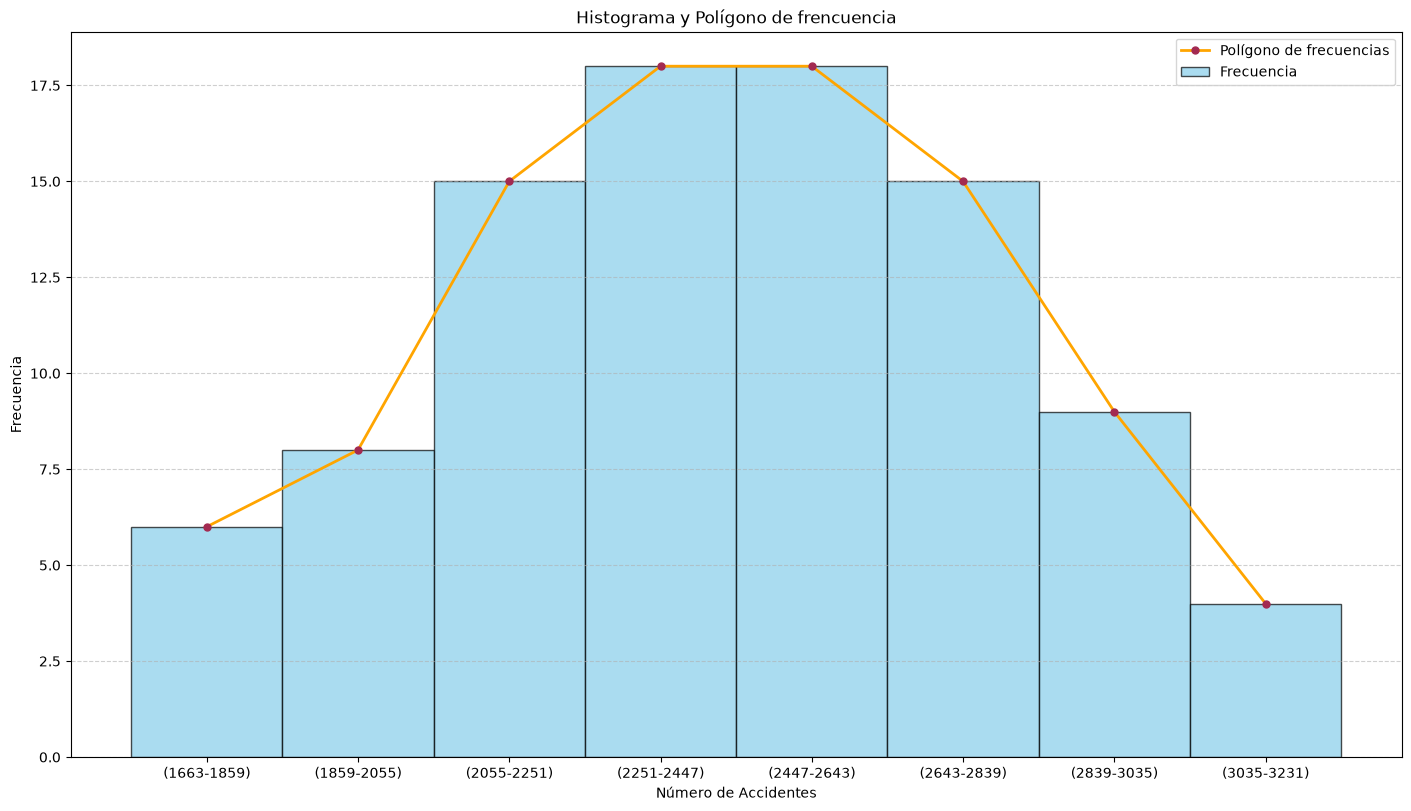

In [40]:
# Histograma y polígono de frecuencia de la variable Accidentes

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(df["Accidentes"], bins=8)

# Crear un array con los intervalos
bins = []
for index, value in enumerate(intervalos):
    if index <= 7:
        bins.append((int(value), int(intervalos[index+1])))

# Calcular las marcas de clase
Marcas_de_clase = [(a+b)/2 for a, b in bins]

# Cambiar el formato de los intervalos para el eje x
labels = [f"({a}-{b})" for a,b in bins]

# Calcular las anchuras de clase
Anchura = (bins[0][1] - bins[0][0])

plt.figure(figsize=(14,8), constrained_layout=True)
plt.bar(Marcas_de_clase, frecuencias, width=Anchura, align='center', edgecolor='black', color="skyblue",alpha=0.7,label="Frecuencia")
plt.plot(Marcas_de_clase, frecuencias, marker=".", markersize=10, markerfacecolor="#a32a51", markeredgecolor="#a32a51", linestyle="solid",
        linewidth=2, color="orange", label="Polígono de frecuencias")
plt.xticks(Marcas_de_clase, labels)
plt.title("Histograma y Polígono de frencuencia")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")



# Cuadrícula y leyenda
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.show()


El histograma muestra que la mayoría de los meses presentan entre aproximadamente 2251 y 2643 accidentes, concentración que coincide con el intervalo de mayor frecuencia (18 meses en cada uno de los dos intervalos centrales). La distribución cae de forma bastante simétrica hacia ambos lados de ese centro. Los valores extremos son poco frecuentes: 6 meses registran entre 1663 y 1859 accidentes, y apenas 4 meses superan los 3035. Esto sugiere una distribución simétrica.

In [46]:
# Calcular las medidas de tendencia central de la variable Accidentes

media = df["Accidentes"].mean()
mediana = df["Accidentes"].median()
moda = df["Accidentes"].mode()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: ")
for x in moda:
    print(x)

Media: 2440.47
Mediana: 2435.0
Moda: 
1967
2269
2457


La media de 2440.47 y la mediana de 2435.0 son muy cercanas entre sí, lo que confirma la simetría observada en el histograma: no hay indicios de sesgo marcado ni de valores extremos que distorsionen el promedio. Tambien se puede observar que la variable accidentes es multimodal (1967, 2269 y 2457), con cada valor repitiéndose solo 2 veces, esto significa que pierde utilidad como medida de tendencia central, ya que no logra capturar un "valor típico".

In [49]:
# Calcular las medidas de dispersión de la variable Accidentes.

print(f"Rango: {df["Accidentes"].max()-df["Accidentes"].min():.2f}")
print(f"Varianza: {df["Accidentes"].var(ddof=0):.2f}")
print(f"Desviación estándar: {df["Accidentes"].std(ddof=0):.2f}")
cv = (df["Accidentes"].std() / df["Accidentes"].mean()) * 100
print(f"Coeficiente de variación: {cv:.2f}%")

Rango: 1568.00
Varianza: 131625.52
Desviación estándar: 362.80
Coeficiente de variación: 14.95%


La variable Accidentes presenta una desviación estándar de 362.80, lo que indica que los valores mensuales se alejan en promedio ±363 accidentes respecto a la media de 2440.47. El coeficiente de variación (14.95%) confirma que esta dispersión es baja-moderada en términos relativos, sugiriendo que, si bien existen fluctuaciones mes a mes, el comportamiento de la accidentalidad es relativamente estable a lo largo del periodo analizado, sin cambios extremos o erráticos. 